● Fetch product data from API
● Analyze product prices
● Compare product ratings
● Visualize category performance
● Generate sales insights
● Filter and sort products

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import requests 

my_request = requests.get("https://fakestoreapi.com/products")

print(my_request.status_code)
if my_request.status_code == 200:
	data = my_request.json()
	print(data)
else:
	print("Failed to fetch products:", my_request.text)

200
[{'id': 1, 'title': 'Fjallraven - Foldsack No. 1 Backpack, Fits 15 Laptops', 'price': 109.95, 'description': 'Your perfect pack for everyday use and walks in the forest. Stash your laptop (up to 15 inches) in the padded sleeve, your everyday', 'category': "men's clothing", 'image': 'https://fakestoreapi.com/img/81fPKd-2AYL._AC_SL1500_t.png', 'rating': {'rate': 3.9, 'count': 120}}, {'id': 2, 'title': 'Mens Casual Premium Slim Fit T-Shirts ', 'price': 22.3, 'description': 'Slim-fitting style, contrast raglan long sleeve, three-button henley placket, light weight & soft fabric for breathable and comfortable wearing. And Solid stitched shirts with round neck made for durability and a great fit for casual fashion wear and diehard baseball fans. The Henley style round neckline includes a three-button placket.', 'category': "men's clothing", 'image': 'https://fakestoreapi.com/img/71-3HjGNDUL._AC_SY879._SX._UX._SY._UY_t.png', 'rating': {'rate': 4.1, 'count': 259}}, {'id': 3, 'title': 'Mens

In [2]:
df=pd.DataFrame(data)
print(df.to_string())

    id                                                                                              title   price                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           description          category                                                                     image                     

In [3]:
print("Highest Price Product")

highest = df.loc[df["price"].idxmax()]

print(highest["title"])
print(highest["price"])

lowest = df.loc[df["price"].idxmin()]

print("\nLowest Price Product")

print(lowest["title"])
print(lowest["price"])

print("\nAverage Price")

print(df["price"].mean())

print(df["price"].sum())


# avg=df.groupby('category')['price'].mean()
# print(avg)

# plt.plot(avg)
# plt.show()

Highest Price Product
Samsung 49-Inch CHG90 144Hz Curved Gaming Monitor (LC49HG90DMNXZA) – Super Ultrawide Screen QLED 
999.99

Lowest Price Product
Opna Women's Short Sleeve Moisture
7.95

Average Price
162.04599999999996
3240.919999999999


In [16]:
# df["rating"] = [x["rate"] for x in data]
# df["reviews"] = [x["count"] for x in data]

# top = df.sort_values("rating", ascending=False)

# print(top[["title","rating"]].head())

# most_reviewed = df.sort_values("reviews", ascending=False)

# print(most_reviewed[["title","reviews"]].head())





category
electronics         332.498333
jewelery            220.995000
men's clothing       51.057500
women's clothing     26.286667
Name: price, dtype: float64


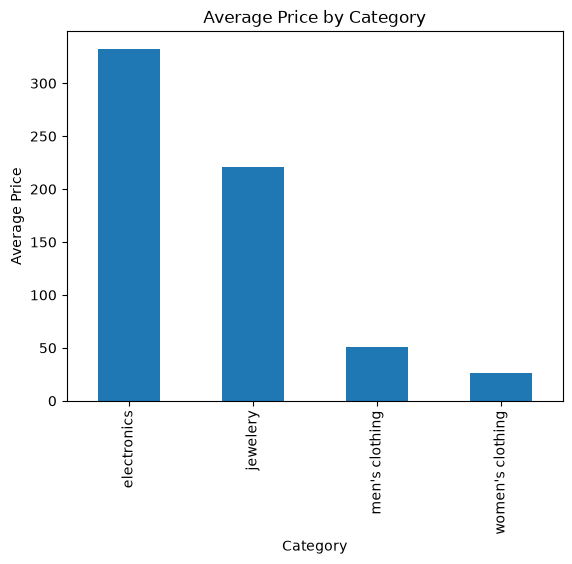

In [18]:
category_price = df.groupby("category")["price"].mean()

print(category_price)


category_price.plot(kind="bar")

plt.title("Average Price by Category")

plt.xlabel("Category")

plt.ylabel("Average Price")

plt.show()





In [19]:
# popular = df.sort_values("reviews", ascending=False)

# print(popular[["title","reviews"]].head())

print(df.groupby("category")["price"].mean().sort_values(ascending=False))



category
electronics         332.498333
jewelery            220.995000
men's clothing       51.057500
women's clothing     26.286667
Name: price, dtype: float64


In [ ]:
expensive = df[df["price"] > 100]

print(expensive[["title","price"]])

electronics = df[df["category"] == "electronics"]

print(electronics)

# good = df[df["rating"] > 4]

# print(good[["title","rating"]])

In [ ]:

print(df.sort_values("price", ascending=False).to_string())


    id                                                                                              title   price                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           description          category                                                                     image  rating reviews
13  

In [24]:
print(df.sort_values("rating", ascending=False))

    id                                              title   price  \
11  12  WD 4TB Gaming Drive Works with Playstation 4 P...  114.00   
10  11  Silicon Power 256GB SSD 3D NAND A55 SLC Cache ...  109.00   
2    3                                 Mens Cotton Jacket   55.99   
17  18        MBJ Women's Solid Short Sleeve Boat Neck V     9.85   
4    5  John Hardy Women's Legends Naga Gold & Silver ...  695.00   
18  19                 Opna Women's Short Sleeve Moisture    7.95   
1    2             Mens Casual Premium Slim Fit T-Shirts    22.30   
0    1  Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...  109.95   
5    6                       Solid Gold Petite Micropave   168.00   
16  17  Rain Jacket Women Windbreaker Striped Climbing...   39.99   
19  20         DANVOUY Womens T Shirt Casual Cotton Short   12.99   
8    9  WD 2TB Elements Portable External Hard Drive -...   64.00   
6    7                         White Gold Plated Princess    9.99   
12  13  Acer SB220Q bi 21.5 inches

In [22]:
print(df[['id','title','price','category','rating']].to_string())

df.to_csv("product_report.csv", index=False)

print("Report Saved")

    id                                                                                              title   price          category  rating
0    1                                              Fjallraven - Foldsack No. 1 Backpack, Fits 15 Laptops  109.95    men's clothing     3.9
1    2                                                             Mens Casual Premium Slim Fit T-Shirts    22.30    men's clothing     4.1
2    3                                                                                 Mens Cotton Jacket   55.99    men's clothing     4.7
3    4                                                                               Mens Casual Slim Fit   15.99    men's clothing     2.1
4    5                        John Hardy Women's Legends Naga Gold & Silver Dragon Station Chain Bracelet  695.00          jewelery     4.6
5    6                                                                       Solid Gold Petite Micropave   168.00          jewelery     3.9
6    7              